# Análisis exploratorio de datos - Airlines

**Autor:** Edisson Prieto

Este notebook explora el dataset `airlines.csv`, que contiene información de vuelos (aerolínea, aeropuertos de origen/destino, día de la semana, hora, duración) y una variable objetivo `Delay` que indica si el vuelo tuvo retraso (1) o no (0).

Objetivos de esta exploración:
1. Entender la estructura y calidad de los datos (tipos, nulos, duplicados).
2. Describir estadísticamente las variables numéricas y categóricas.
3. Analizar la variable objetivo `Delay` y su relación con las demás variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Carga de datos

In [2]:
airlines = pd.read_csv("../data/airlines.csv")
airlines.shape

(539383, 8)

In [3]:
airlines.head()

,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,CO,269,SFO,IAH,3,15,205,1
1,US,1558,PHX,CLT,3,15,222,1
2,AA,2400,LAX,DFW,3,20,165,1
3,AA,2466,SFO,DFW,3,20,195,1
4,AS,108,ANC,SEA,3,30,202,0


## 2. Estructura y calidad de los datos

In [4]:
airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Airline      539383 non-null  object
 1   Flight       539383 non-null  int64 
 2   AirportFrom  539383 non-null  object
 3   AirportTo    539383 non-null  object
 4   DayOfWeek    539383 non-null  int64 
 5   Time         539383 non-null  int64 
 6   Length       539383 non-null  int64 
 7   Delay        539383 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 32.9+ MB


In [5]:
# Valores nulos por columna
airlines.isna().sum()

Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

In [6]:
# Filas duplicadas
airlines.duplicated().sum()

216618

In [7]:
# Cardinalidad de cada columna
airlines.nunique().sort_values(ascending=False)

Flight         6585
Time           1131
Length          426
AirportFrom     293
AirportTo       293
Airline          18
DayOfWeek         7
Delay             2
dtype: int64

El dataset no tiene valores nulos ni columnas con tipos mixtos. `Flight`, `AirportFrom` y `AirportTo` son identificadores con alta cardinalidad, mientras que `Airline`, `DayOfWeek` y `Delay` son categóricas de baja cardinalidad.

## 3. Estadísticas descriptivas - variables numéricas

In [8]:
airlines[["Time", "Length"]].describe()

,Time,Length
count,539383.000000,539383.000000
mean,802.728963,132.202007
std,278.045911,70.117016
min,10.000000,0.000000
25%,565.000000,81.000000
50%,795.000000,115.000000
75%,1035.000000,162.000000
max,1439.000000,655.000000


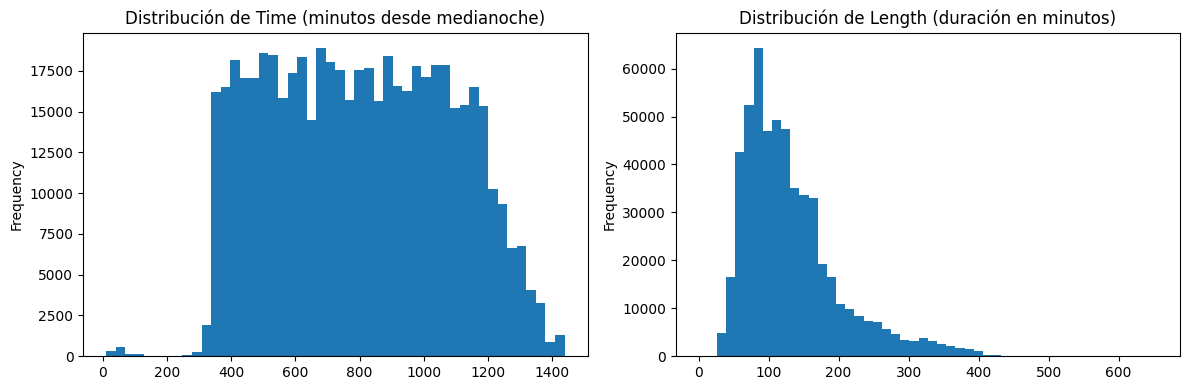

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
airlines["Time"].plot(kind="hist", bins=48, ax=axes[0], title="Distribución de Time (minutos desde medianoche)")
airlines["Length"].plot(kind="hist", bins=50, ax=axes[1], title="Distribución de Length (duración en minutos)")
plt.tight_layout()
plt.show()

`Time` representa minutos desde medianoche (0-1439) y muestra la actividad típica de un día de operaciones aéreas, con menor densidad en horas de madrugada. `Length` (duración del vuelo en minutos) tiene una distribución sesgada a la derecha, con la mayoría de vuelos entre 1 y 3 horas y una cola larga de vuelos de larga distancia.

## 4. Variables categóricas

In [10]:
airlines["Airline"].value_counts()

Airline
WN    94097
DL    60940
OO    50254
AA    45656
MQ    36605
US    34500
XE    31126
EV    27983
UA    27619
CO    21118
FL    20827
9E    20686
B6    18112
YV    13725
OH    12630
AS    11471
F9     6456
HA     5578
Name: count, dtype: int64

In [11]:
airlines["DayOfWeek"].value_counts().sort_index()

DayOfWeek
1    72769
2    71340
3    89746
4    91445
5    85248
6    58956
7    69879
Name: count, dtype: int64

In [12]:
top_airports_from = airlines["AirportFrom"].value_counts().head(10)
top_airports_to = airlines["AirportTo"].value_counts().head(10)
pd.DataFrame({"AirportFrom": top_airports_from, "AirportTo": top_airports_to})

,AirportFrom,AirportTo
ATL,34449,34440
ORD,24822,24871
DFW,22154,22153
DEN,19843,19848
LAX,16657,16656
IAH,15821,15819
PHX,15557,15558
DTW,13136,13146
LAS,11918,11918
SFO,11786,11792


## 5. Variable objetivo: Delay

In [13]:
delay_counts = airlines["Delay"].value_counts(normalize=True).sort_index()
delay_counts

Delay
0    0.554558
1    0.445442
Name: proportion, dtype: float64

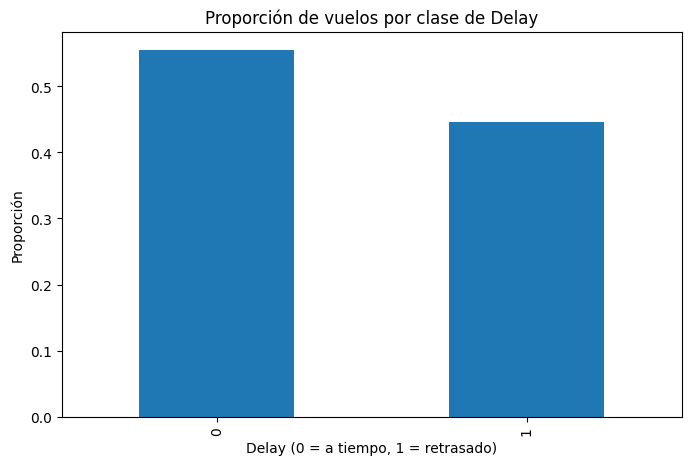

In [14]:
delay_counts.plot(kind="bar", title="Proporción de vuelos por clase de Delay")
plt.xlabel("Delay (0 = a tiempo, 1 = retrasado)")
plt.ylabel("Proporción")
plt.show()

La clase está moderadamente desbalanceada: alrededor de 55.5% de los vuelos no tienen retraso y 44.5% sí lo tienen. No es un desbalance extremo, pero conviene tenerlo en cuenta al entrenar modelos (p. ej. usando métricas distintas a accuracy).

## 6. Relación entre Delay y otras variables

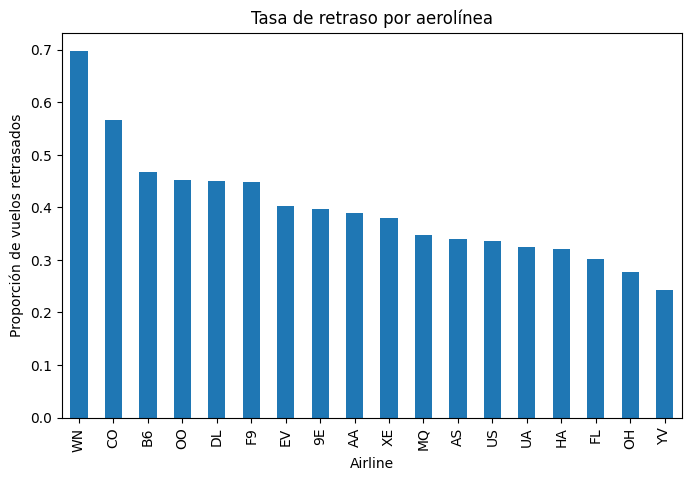

In [15]:
delay_by_airline = airlines.groupby("Airline")["Delay"].mean().sort_values(ascending=False)
delay_by_airline.plot(kind="bar", title="Tasa de retraso por aerolínea")
plt.ylabel("Proporción de vuelos retrasados")
plt.show()

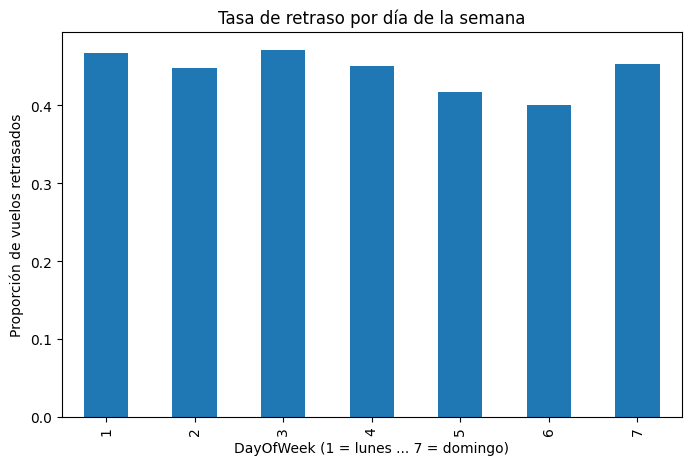

In [16]:
delay_by_dow = airlines.groupby("DayOfWeek")["Delay"].mean().sort_index()
delay_by_dow.plot(kind="bar", title="Tasa de retraso por día de la semana")
plt.xlabel("DayOfWeek (1 = lunes ... 7 = domingo)")
plt.ylabel("Proporción de vuelos retrasados")
plt.show()

/var/folders/b4/j6tyv5517psbg3_x20f10x5r0000gn/T/ipykernel_45074/1585787657.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_hour = airlines.groupby(hour_bins)["Delay"].mean()


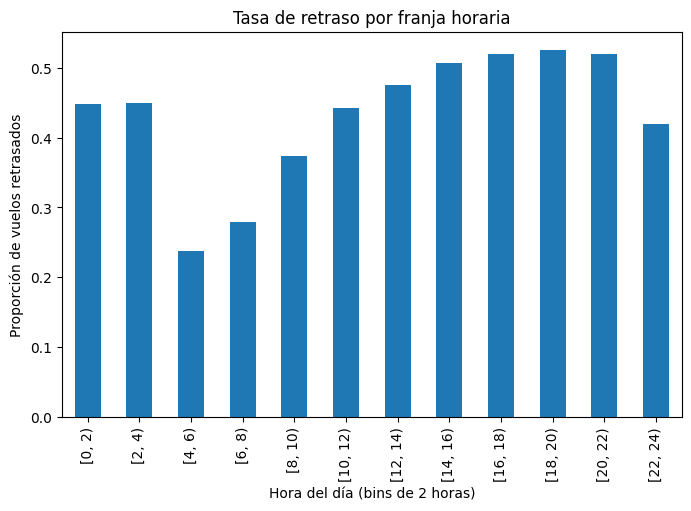

In [17]:
# Tasa de retraso por franja horaria (bins de 2 horas)
hour_bins = pd.cut(airlines["Time"] / 60, bins=range(0, 25, 2), right=False)
delay_by_hour = airlines.groupby(hour_bins)["Delay"].mean()
delay_by_hour.plot(kind="bar", title="Tasa de retraso por franja horaria")
plt.xlabel("Hora del día (bins de 2 horas)")
plt.ylabel("Proporción de vuelos retrasados")
plt.show()

In [18]:
airlines.groupby("Delay")["Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Delay,,,,,,,,
0,299119.0,129.657594,68.693898,0.0,81.0,114.0,159.0,655.0
1,240264.0,135.369697,71.723475,0.0,82.0,118.0,166.0,655.0


## 7. Correlación entre variables numéricas

In [19]:
numeric_cols = ["DayOfWeek", "Time", "Length", "Delay"]
corr = airlines[numeric_cols].corr()
corr

,DayOfWeek,Time,Length,Delay
DayOfWeek,1.000000,0.001273,0.013397,-0.026199
Time,0.001273,1.000000,-0.020612,0.150454
Length,0.013397,-0.020612,1.000000,0.040489
Delay,-0.026199,0.150454,0.040489,1.000000


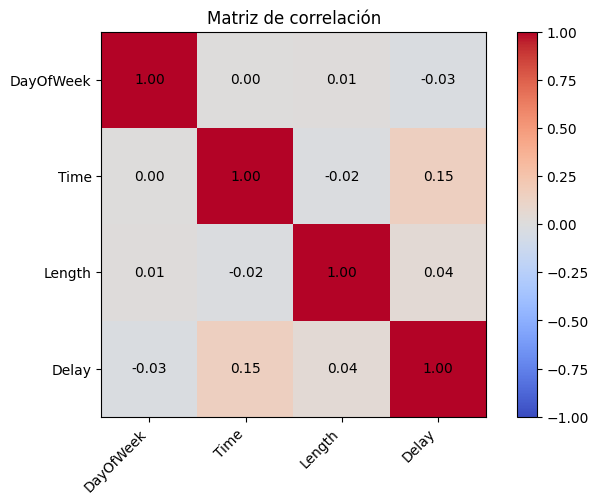

In [20]:
fig, ax = plt.subplots()
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_cols)), labels=numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)), labels=numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Matriz de correlación")
plt.show()

## 8. Conclusiones

- El dataset está completo (sin nulos ni duplicados) y contiene 539,383 vuelos de 18 aerolíneas distintas.
- La variable objetivo `Delay` está moderadamente desbalanceada (~55.5% a tiempo vs ~44.5% retrasado).
- La tasa de retraso varía notablemente entre aerolíneas, lo que sugiere que `Airline` puede ser una variable predictiva relevante.
- La hora del día (`Time`) también muestra variación en la tasa de retraso, con franjas horarias más propensas a retrasos que otras (usualmente hacia el final del día, por efecto acumulado de retrasos previos).
- `DayOfWeek` y `Length` muestran una relación más débil con `Delay` en términos de correlación lineal, pero pueden aportar valor en combinación con otras variables o mediante transformación (p. ej. agrupar por franja horaria en lugar de usar `Time` como continua).
- Para un modelo predictivo, sería razonable: codificar `Airline`, `AirportFrom`/`AirportTo` (posiblemente agrupando aeropuertos poco frecuentes), y usar `Time` tanto en forma continua como en franjas horarias.